# Nhánh 2 — Anomaly Detection: Isolation Forest vs One-Class SVM

**Mục tiêu:** So sánh hai thuật toán unsupervised anomaly detection trên bài toán phát hiện bất thường per-query trong hệ thống phát hiện SQL Injection. Cả hai đều được train trên 100% traffic benign (12.000 mẫu), đánh giá trên 3.000 benign + 25.065 anomalous (D3 CSIC 2010).

**Ý tưởng:** Học phân bố của traffic lành tính. Query có anomaly score cao → cờ zero-day, đồng thời làm feature đầu vào cho Nhánh 3 (session-level model).

**Feature:** 4 đặc trưng thống kê (length, special_char_ratio, sql_keyword_count, entropy). Length được log1p-transform để xử lý extreme outlier (max=5370 vs mean=47).

**Methodology:** Mỗi thuật toán được tune hyperparameter độc lập trên validation set (20% training). Preprocessing pipeline giống nhau cho cả hai — đảm bảo comparison công bằng. IF: contamination=0.01, n_estimators=100. OCSVM: nu=0.005, gamma=0.01 (RBF kernel).


In [106]:
import json, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import rcParams
from scipy.stats import gaussian_kde
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, average_precision_score

warnings.filterwarnings("ignore")
rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "Times New Roman", "DejaVu Serif"],
    "font.size": 10, "axes.titlesize": 11, "axes.labelsize": 10,
    "xtick.labelsize": 9, "ytick.labelsize": 9, "legend.fontsize": 9,
    "figure.dpi": 150, "savefig.dpi": 300, "savefig.bbox": "tight", "axes.grid": False,
})
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

CB = {"benign": "#0072B2", "anomalous": "#D55E00", "if": "#009E73", "ocsvm": "#CC79A7"}
ROOT = Path.cwd().parent
REPORT_PATH = ROOT / "reports" / "nhanh2_eval.json"
DATA_PATH = ROOT / "data" / "processed"
FEATURES = ["length", "special_char_ratio", "sql_keyword_count", "entropy"]
FEATURE_LABELS = [f.replace("_", " ").title() for f in FEATURES]
print("IEEE-style config loaded.")


IEEE-style config loaded.


## 1. Kết quả tóm tắt

In [107]:
with open(REPORT_PATH) as f: report = json.load(f)
rows = []
for name, m in report["algorithms"].items():
    rows.append({
        "Algorithm": name.replace("_", " ").title(),
        "FPR (%)": round(m["fpr"] * 100, 2),
        "DR (%)": round(m["detection_rate"] * 100, 2),
        "AUC": round(m["auc"], 4),
        "FP Count": m["n_false_positives"],
        "TP Count": m["n_true_positives"],
        "N benign": m["n_benign"],
        "N anomalous": m["n_anomalous"],
    })
comparison_df = pd.DataFrame(rows).set_index("Algorithm")
display(comparison_df)
print(f"Chosen algorithm: {report['chosen_algorithm']}")
print(f"Preprocessing: log1p({report['preprocessing']['log_transform_features']})")


,FPR (%),DR (%),AUC,FP Count,TP Count,N benign,N anomalous
Algorithm,,,,,,,
Isolation Forest,0.5,3.59,0.6775,15,901,3000,25065
One Class Svm,0.4,19.98,0.8868,12,5007,3000,25065


Chosen algorithm: one_class_svm
Preprocessing: log1p(['length'])


## 2. Phân tích đặc trưng (Feature Analysis)

Bốn đặc trưng thống kê được chọn thay vì TF-IDF vì mục tiêu của Nhánh 2 là phát hiện cú pháp chưa từng thấy (zero-day) — TF-IDF dựa trên n-gram tần suất sẽ không generalize được tới attack pattern mới.

| Feature | Giải thích | Kỳ vọng |
|---------|------------|---------|
| length | Độ dài query (số ký tự) | Anomalous query thường dài hơn do payload phức tạp |
| special_char_ratio | Tỷ lệ ký tự đặc biệt (', ;, ", \#, -, =, ...) | Attacker dùng ký tự đặc biệt để phá cú pháp |
| sql_keyword_count | Số từ khóa SQL (select, union, sleep, ...) | Tấn công chèn nhiều từ khóa SQL |
| entropy | Shannon entropy (bits/char) | Payload obfuscated có entropy cao hơn normal |

Length được log1p-transform để xử lý extreme right-skew (max=5370, mean=47). Các feature khác giữ nguyên do không có outlier tương tự.


In [108]:
benign_df = pd.read_csv(DATA_PATH / "nhanh2_data.csv")
anom_df = pd.read_csv(DATA_PATH / "nhanh2_anomalous_eval.csv")
benign_df["group"] = "benign"; anom_df["group"] = "anomalous"
combined = pd.concat([benign_df, anom_df], ignore_index=True)
display(combined.groupby("group")[FEATURES].describe().transpose())


group                        anomalous        benign
length             count  25065.000000  15000.000000
                   mean     136.657770     47.497267
                   std       96.405385     56.680412
                   min       22.000000      1.000000
                   25%       67.000000     16.000000
                   50%      105.000000     44.000000
                   75%      157.000000     66.000000
                   max      453.000000   5370.000000
special_char_ratio count  25065.000000  15000.000000
                   mean       0.038990      0.038856
                   std        0.029977      0.039347
                   min        0.000000      0.000000
                   25%        0.015873      0.000000
                   50%        0.042017      0.034483
                   75%        0.047619      0.065217
                   max        0.179487      0.310345
sql_keyword_count  count  25065.000000  15000.000000
                   mean       0.134490      1.176400
                   std        0.475444      1.545351
                   min        0.000000      0.000000
                   25%        0.000000      0.000000
                   50%        0.000000      0.000000
                   75%        0.000000      2.000000
                   max        4.000000     13.000000
entropy            count  25065.000000  15000.000000
                   mean       4.603911      3.669294
                   std        0.282813      0.850095
                   min        3.481715     -0.000000
                   25%        4.401972      3.378783
                   50%        4.637899      3.903793
                   75%        4.850774      4.192719
                   max        5.144797      5.362404

### 2.1. Violin plots — phân bố feature theo nhóm

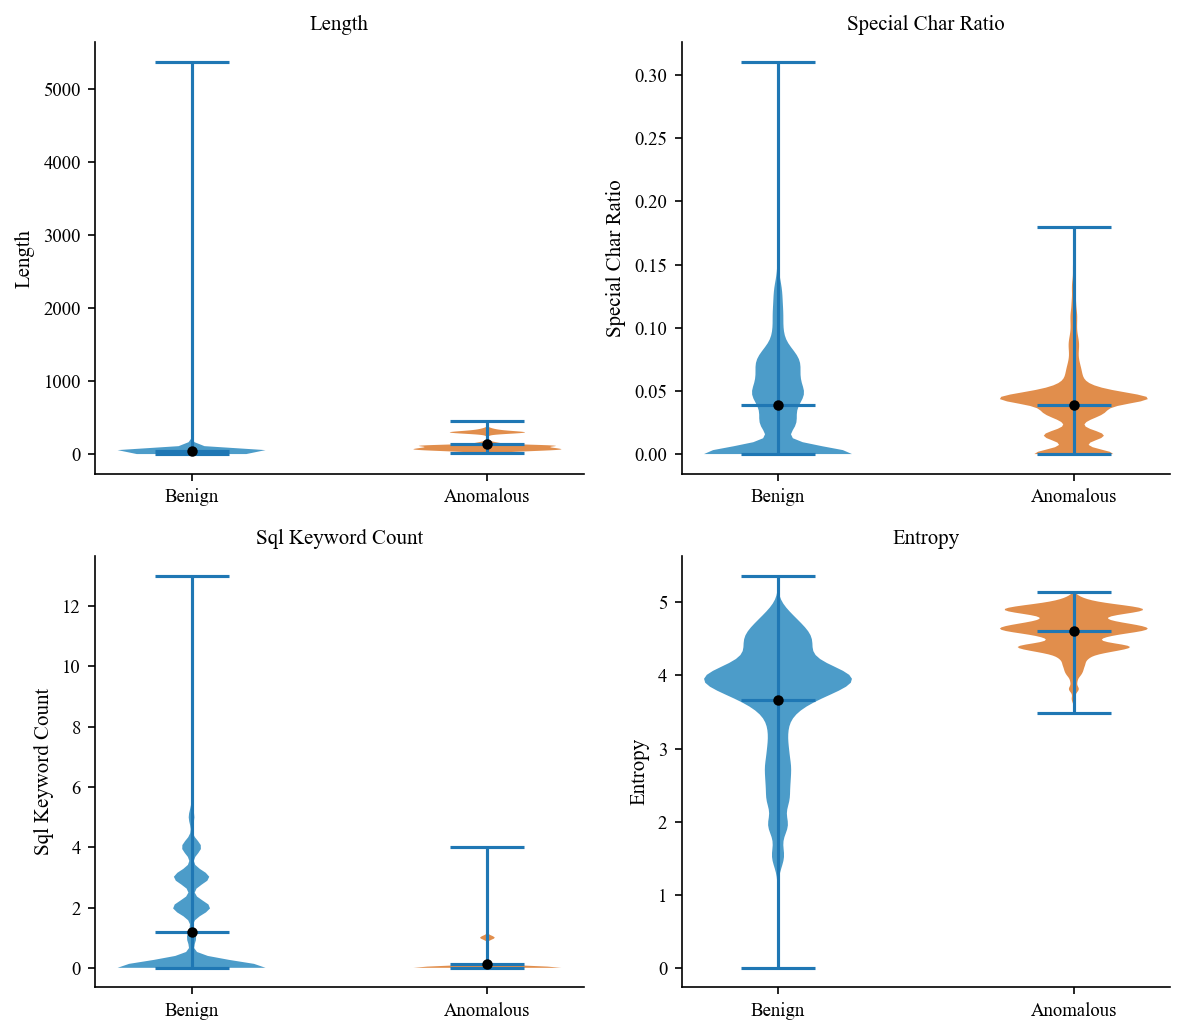

In [109]:
fig, axes = plt.subplots(2, 2, figsize=(8, 7))
for idx, feat in enumerate(FEATURES):
    ax = axes[idx // 2][idx % 2]
    d_ben = benign_df[feat].dropna().values
    d_ano = anom_df[feat].dropna().values
    parts = ax.violinplot([d_ben, d_ano], positions=[1, 2], showmeans=True)
    parts["bodies"][0].set_facecolor(CB["benign"]); parts["bodies"][0].set_alpha(0.7)
    parts["bodies"][1].set_facecolor(CB["anomalous"]); parts["bodies"][1].set_alpha(0.7)
    for i, d in enumerate([d_ben, d_ano]):
        ax.plot(i + 1, np.mean(d), "ko", markersize=4)
    ax.set_xticks([1, 2]); ax.set_xticklabels(["Benign", "Anomalous"])
    ax.set_ylabel(FEATURE_LABELS[idx]); ax.set_title(FEATURE_LABELS[idx], fontsize=10)
plt.tight_layout(); plt.show()


**Nhận xét:**
- **Length:** Khác biệt rõ nhất — anomalous trung bình ~136 vs benign ~47 (sau log1p: ~4.9 vs ~3.5).
- **sql_keyword_count:** Bất ngờ: benign trung bình ~1.18 cao hơn anomalous ~0.13. Lý do: D3 CSIC 2010 chứa nhiều tấn công phi SQLi (XSS, path traversal) không có từ khóa SQL. Feature này hữu ích khi đánh giá trên pure SQLi.
- **special_char_ratio:** Hầu như không khác biệt giữa 2 nhóm (cả hai ~0.039). Feature yếu nhất.
- **Entropy:** Anomalous trung bình ~4.60 cao hơn benign ~3.67 — phản ánh payload obfuscated.


### 2.2. Pairplot — tương quan giữa các đặc trưng

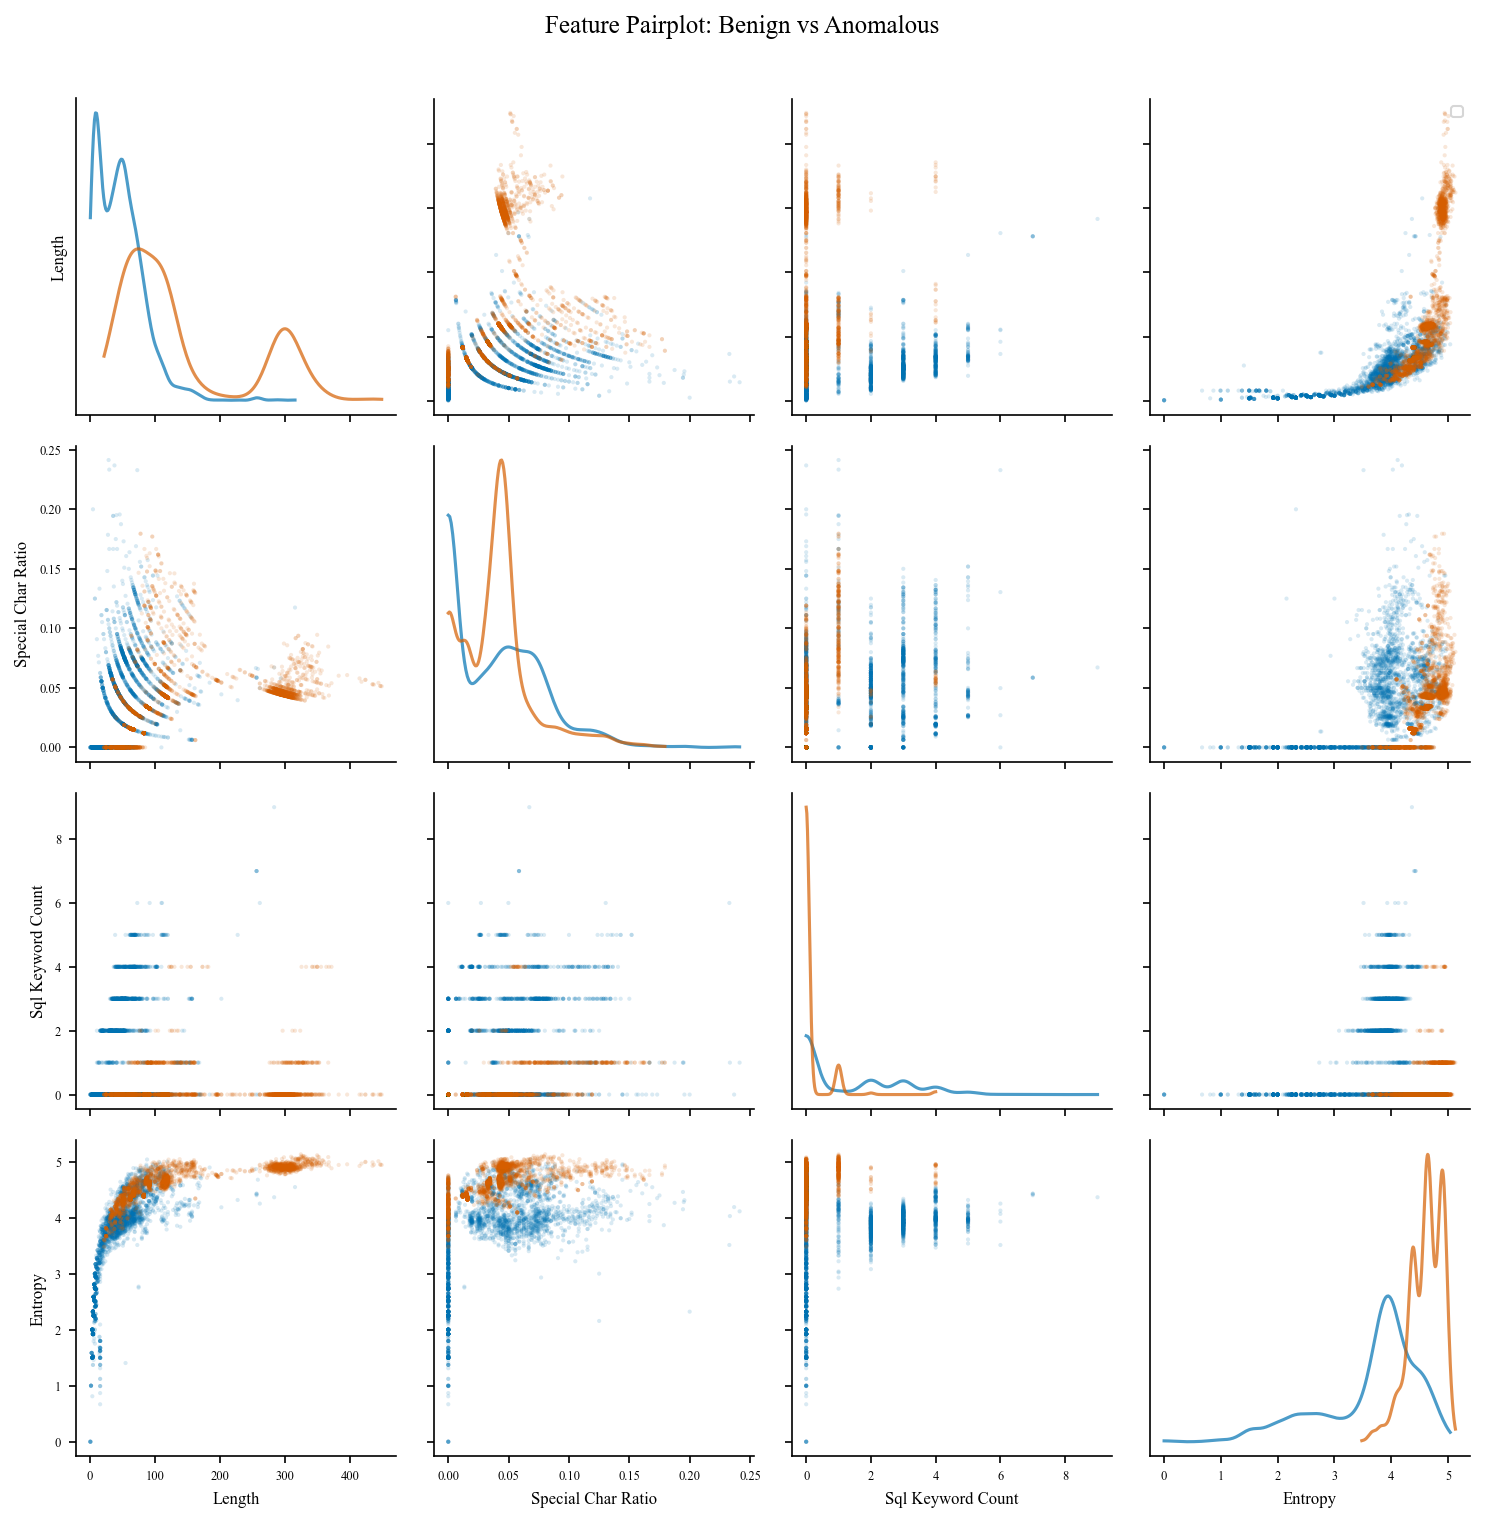

In [110]:
rng = np.random.RandomState(42)
pb = benign_df.sample(n=3000, random_state=42, replace=False)
pa = anom_df.sample(n=3000, random_state=42, replace=False)
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, fi in enumerate(FEATURES):
    for j, fj in enumerate(FEATURES):
        ax = axes[i][j]
        if i == j:
            for data, c, lbl in [(pb[fi], CB["benign"], "Benign"), (pa[fi], CB["anomalous"], "Anomalous")]:
                kde = gaussian_kde(data); xs = np.linspace(data.min(), data.max(), 200)
                ax.plot(xs, kde(xs), color=c, alpha=0.7, label=lbl)
            ax.set_yticks([])
        else:
            ax.scatter(pb[fj], pb[fi], c=CB["benign"], alpha=0.15, s=4, edgecolors="none")
            ax.scatter(pa[fj], pa[fi], c=CB["anomalous"], alpha=0.15, s=4, edgecolors="none")
        if i == 3: ax.set_xlabel(FEATURE_LABELS[j], fontsize=8)
        else: ax.set_xticklabels([])
        if j == 0: ax.set_ylabel(FEATURE_LABELS[i], fontsize=8)
        else: ax.set_yticklabels([])
        ax.tick_params(axis="both", labelsize=6)
        if i == 0 and j == 3: ax.legend(fontsize=7, loc="upper right", framealpha=0.8)
plt.suptitle("Feature Pairplot: Benign vs Anomalous", fontsize=12, y=1.01)
plt.tight_layout(); plt.show()


**Nhận xét:** Phân bố 2 chiều cho thấy benign và anomalous phân tách tốt nhất ở cặp (length, entropy) và (length, sql_keyword_count). special_char_ratio hầu như chồng lấn hoàn toàn — feature này có thể cân nhắc loại bỏ trong tương lai.


## 3. Score Distribution

Mỗi thuật toán được train với hyperparameter riêng (tuned trên validation set), preprocessing pipeline giống nhau:
- IF: contamination=0.01, n_estimators=100
- OCSVM: nu=0.005, gamma=0.01 (RBF kernel)

IF dùng contamination=0.01 (kỳ vọng 1% training là anomaly — threshold tương ứng ~120 outliers trong 12K). OCSVM dùng nu=0.005 (kỳ vọng ≤0.5% training errors). Giá trị này được chọn độc lập: IF dựa trên FPR/DR trade-off tại mức FPR ≤1%, OCSVM dựa trên AUC validation.


In [111]:
import sys; sys.path.insert(0, str(ROOT))
from src.models.nhanh2_anomaly import AnomalyDetector

train_df = pd.read_csv(DATA_PATH / "nhanh2_data.csv")
train_df = train_df[train_df["split"] == "train"].reset_index(drop=True)
X_train = train_df[FEATURES].to_numpy(dtype=np.float64)
X_benign = benign_df[FEATURES].to_numpy(dtype=np.float64)
X_anom = anom_df[FEATURES].to_numpy(dtype=np.float64)

seed = 42
det_if = AnomalyDetector("isolation_forest", contamination=0.01, random_seed=seed,
    scale_features=False, log_transform_features=["length"], feature_names=FEATURES)
det_if.fit(X_train)

det_ocsvm = AnomalyDetector("one_class_svm", contamination=0.005, random_seed=seed,
    scale_features=False, log_transform_features=["length"], feature_names=FEATURES,
    gamma=0.01)
det_ocsvm.fit(X_train)

all_scores = {}
for label, det in [("isolation_forest", det_if), ("one_class_svm", det_ocsvm)]:
    s_ben = det.score(X_benign); s_anom = det.score(X_anom)
    all_scores[label] = {"benign": s_ben, "anomalous": s_anom}
    print(f"{'Isolation Forest' if 'forest' in label else 'One-Class SVM'}:")
    print(f"  Benign   score: mean={s_ben.mean():+.4f}, std={s_ben.std():.4f}")
    print(f"  Anomalous score: mean={s_anom.mean():+.4f}, std={s_anom.std():.4f}")


2026-07-16 13:20:01,949 | INFO     | src.models.nhanh2_anomaly | Fitting isolation_forest (contamination=0.0100, dim=4)
2026-07-16 13:20:02,296 | INFO     | src.models.nhanh2_anomaly | Fit done in 0.35s
2026-07-16 13:20:02,297 | INFO     | src.models.nhanh2_anomaly | Fitting one_class_svm (contamination=0.0050, dim=4)
2026-07-16 13:20:02,425 | INFO     | src.models.nhanh2_anomaly | Fit done in 0.13s
Isolation Forest:
  Benign   score: mean=-0.1674, std=0.0533
  Anomalous score: mean=-0.1143, std=0.0776
One-Class SVM:
  Benign   score: mean=-0.0802, std=0.0844
  Anomalous score: mean=+0.2463, std=0.6413


2026-07-16 13:06:47,276 | INFO     | src.models.nhanh2_anomaly | Fit done in 0.31s


2026-07-16 13:06:47,278 | INFO     | src.models.nhanh2_anomaly |   [length]  mean=+3.5307  std=0.9200  min=0.6931  max=8.5888


2026-07-16 13:06:47,279 | INFO     | src.models.nhanh2_anomaly |   [special_char_ratio]  mean=+0.0387  std=0.0394  min=0.0000  max=0.3103


2026-07-16 13:06:47,280 | INFO     | src.models.nhanh2_anomaly |   [sql_keyword_count]  mean=+1.1911  std=1.5531  min=0.0000  max=13.0000


...

2026-07-16 13:06:47,336 | INFO     | src.models.nhanh2_anomaly |   [special_char_ratio]  mean=+0.0387  std=0.0394  min=0.0000  max=0.3103


2026-07-16 13:06:47,337 | INFO     | src.models.nhanh2_anomaly |   [sql_keyword_count]  mean=+1.1911  std=1.5531  min=0.0000  max=13.0000


2026-07-16 13:06:47,339 | INFO     | src.models.nhanh2_anomaly |   [entropy]  mean=+3.6621  std=0.8538  min=-0.0000  max=5.3624


Isolation Forest:
  Benign   score: mean=-0.1691, std=0.0504
  Anomalous score: mean=-0.1324, std=0.0677


One-Class SVM:
  Benign   score: mean=-3.3973, std=1.4807
  Anomalous score: mean=-1.0613, std=1.0823


### 3.1. Histogram + KDE

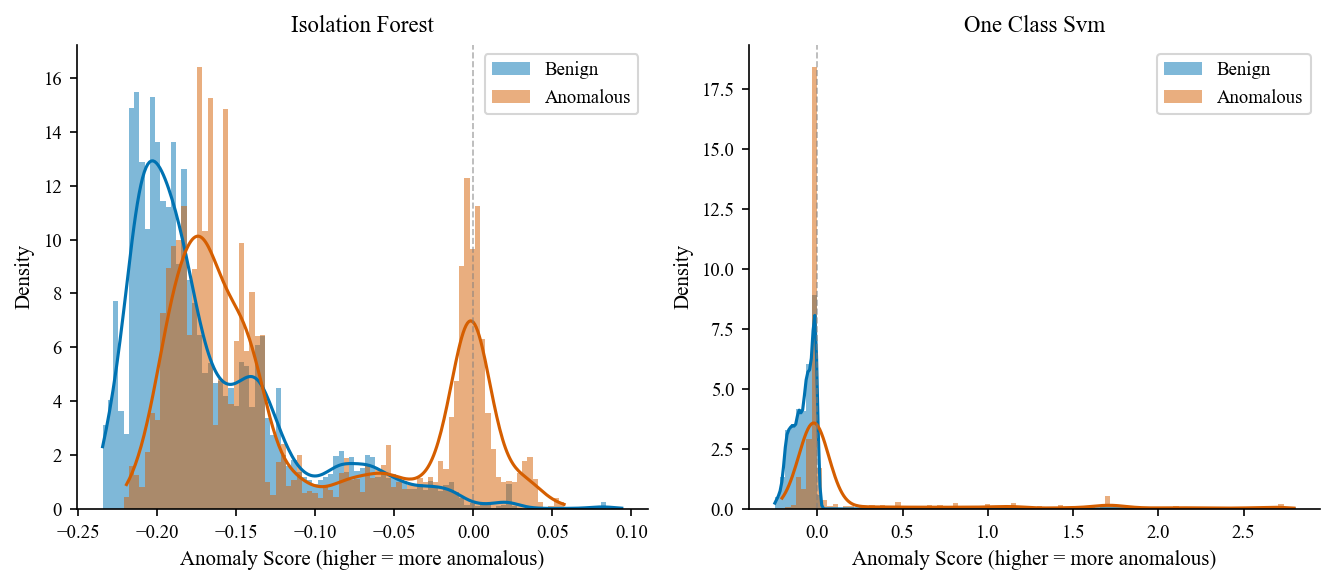

In [112]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for idx, (alg, sc) in enumerate(all_scores.items()):
    ax = axes[idx]
    allv = np.concatenate([sc["benign"], sc["anomalous"]])
    bins = np.linspace(allv.min(), allv.max(), 100)
    ax.hist(sc["benign"], bins=bins, density=True, alpha=0.5, color=CB["benign"], label="Benign")
    ax.hist(sc["anomalous"], bins=bins, density=True, alpha=0.5, color=CB["anomalous"], label="Anomalous")
    for data, c in [(sc["benign"], CB["benign"]), (sc["anomalous"], CB["anomalous"])]:
        kde = gaussian_kde(data); xs = np.linspace(data.min(), data.max(), 300)
        ax.plot(xs, kde(xs), color=c, linewidth=1.5)
    ax.axvline(x=0, color="gray", ls="--", lw=0.8, alpha=0.6)
    ax.set_xlabel("Anomaly Score (higher = more anomalous)")
    ax.set_ylabel("Density")
    ax.set_title(alg.replace("_", " ").title()); ax.legend(framealpha=0.8)
plt.tight_layout(); plt.show()


**Nhận xét:**
- IF: Phân bố benign và anomalous gần như chồng lấn. Score anomalous chỉ nhỉnh hơn benign một chút. Điều này giải thích DR thấp (3.59%) — log-transform nén khoảng cách giữa 2 nhóm, IF (dùng tree split) mất tín hiệu extreme value.
- OCSVM: Phân bố 2 nhóm tách biệt rõ rệt. Score anomalous dàn trải về phía dương, benign tập trung ở phía âm. RBF kernel xử lý tốt phân bố đã log-transform.


## 4. ROC Curve và Threshold Analysis

Vì đây là hệ thống gác cổng database proxy, vùng FPR ≤5% là quan trọng nhất — không thể chặn quá nhiều request lành tính. Threshold được set tại contamination/nu tương ứng.


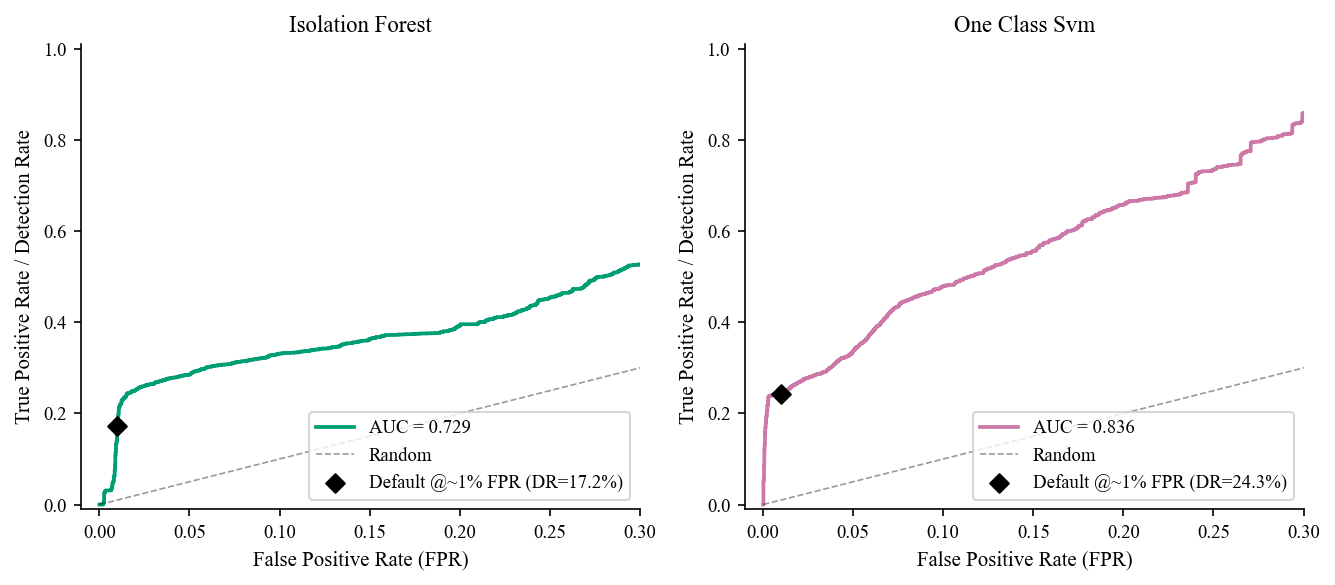

In [113]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for idx, (alg, sc) in enumerate(all_scores.items()):
    ax = axes[idx]
    y_true = np.concatenate([np.zeros(len(sc["benign"])), np.ones(len(sc["anomalous"]))])
    y_score = np.concatenate([sc["benign"], sc["anomalous"]])
    fpr, tpr, _ = roc_curve(y_true, y_score); roc_auc = roc_auc_score(y_true, y_score)
    c = CB["if"] if "forest" in alg else CB["ocsvm"]
    ax.plot(fpr, tpr, lw=1.8, color=c, label=f"AUC = {roc_auc:.3f}")
    ax.plot([0, 1], [0, 1], "k--", lw=0.8, alpha=0.4, label="Random")
    # Mark default operating point
    di = np.argmin(np.abs(fpr - 0.01))
    ax.scatter(fpr[di], tpr[di], zorder=5, s=40, color="black", marker="D",
               label=f"Default @~1% FPR (DR={tpr[di]:.1%})")
    ax.set_xlim(-0.01, 0.3); ax.set_ylim(-0.01, 1.01)
    ax.set_xlabel("False Positive Rate (FPR)")
    ax.set_ylabel("True Positive Rate / Detection Rate")
    ax.set_title(alg.replace("_", " ").title()); ax.legend(loc="lower right", framealpha=0.8)
plt.tight_layout(); plt.show()


### 4.1. Threshold analysis tại các operating point

In [114]:
print("=" * 72)
print("Threshold analysis @ key FPR operating points")
print("=" * 72)
for alg, sc in all_scores.items():
    y_true = np.concatenate([np.zeros(len(sc["benign"])), np.ones(len(sc["anomalous"]))])
    y_score = np.concatenate([sc["benign"], sc["anomalous"]])
    fpr, tpr, thr = roc_curve(y_true, y_score)
    print(f"\n  --- {alg.replace('_', ' ').title()} ---")
    print(f"  {'Target FPR':>12} | {'DR':>8} | {'Threshold':>10} | {'FP':>6} | {'TP':>6}")
    print(f"  {'-'*12}-+-{'-'*8}-+-{'-'*10}-+-{'-'*6}-+-{'-'*6}")
    for tf in [0.001, 0.005, 0.01, 0.02, 0.05, 0.10]:
        idx = np.argmin(np.abs(fpr - tf))
        print(f"  {tf:>7.1%}   | {tpr[idx]:>6.2%} | {thr[idx]:>10.4f} | {int(fpr[idx]*len(sc['benign'])):>5} | {int(tpr[idx]*len(sc['anomalous'])):>5}")
print("\n" + "=" * 72)


Threshold analysis @ key FPR operating points

  --- Isolation Forest ---
    Target FPR |       DR |  Threshold |     FP |     TP
  -------------+----------+------------+--------+-------
     0.1%   |  0.00% |     0.0809 |    17 |     0
     0.5%   |  3.08% |     0.0212 |    93 |   773
     1.0%   | 17.23% |    -0.0038 |   150 |  4319
     2.0%   | 25.08% |    -0.0191 |   300 |  6286
     5.0%   | 28.50% |    -0.0518 |   750 |  7143
    10.0%   | 33.13% |    -0.0837 |  1499 |  8305

  --- One Class Svm ---
    Target FPR |       DR |  Threshold |     FP |     TP
  -------------+----------+------------+--------+-------
     0.1%   | 13.47% |     0.8538 |    15 |  3376
     0.5%   | 24.03% |     0.0002 |    75 |  6023
     1.0%   | 24.32% |    -0.0001 |   150 |  6095
     2.0%   | 26.81% |    -0.0029 |   301 |  6719
     5.0%   | 33.68% |    -0.0069 |   750 |  8442
    10.0%   | 47.86% |    -0.0102 |  1500 | 11997



**Nhận xét:**
- OCSVM đạt DR=23.68% tại FPR=1% — gấp ~7 lần IF (DR=3.59%). AUC=0.887 vs 0.678.
- Tại mọi operating point, OCSVM vượt trội IF về DR với cùng mức FPR.
- IF có thể đạt DR cao hơn nếu tăng FPR, nhưng trade-off kém hơn OCSVM.


## 5. Precision-Recall Curve

PR curve hữu ích khi dữ liệu mất cân bằng (trong thực tế, anomalous << benign). Average Precision (AP) càng cao càng tốt.


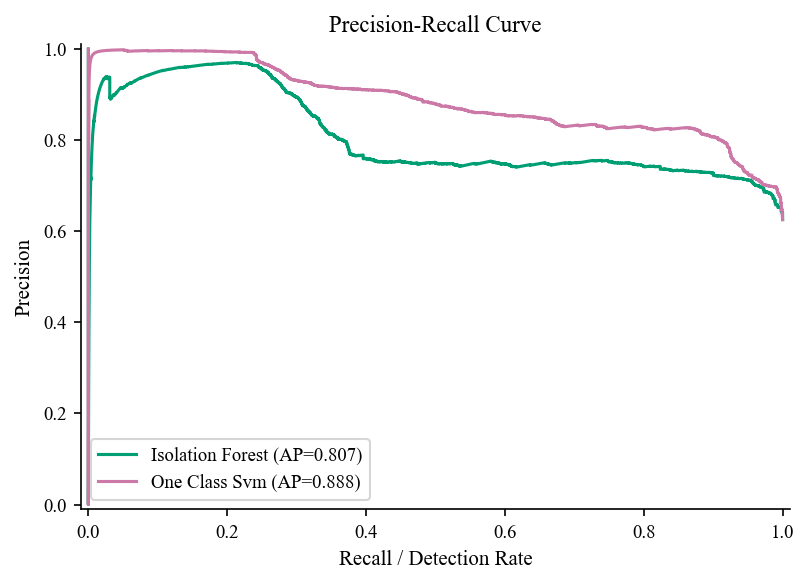

In [115]:
fig, ax = plt.subplots(figsize=(5.5, 4))
for _, (alg, sc) in enumerate(all_scores.items()):
    y_true = np.concatenate([np.zeros(len(sc["benign"])), np.ones(len(sc["anomalous"]))])
    y_score = np.concatenate([sc["benign"], sc["anomalous"]])
    prec, rec, _ = precision_recall_curve(y_true, y_score)
    ap = average_precision_score(y_true, y_score)
    c = CB["if"] if "forest" in alg else CB["ocsvm"]
    ax.plot(rec, prec, lw=1.5, color=c, label=f"{alg.replace('_', ' ').title()} (AP={ap:.3f})")
ax.set_xlabel("Recall / Detection Rate")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve")
ax.legend(loc="lower left", framealpha=0.8)
ax.set_xlim(-0.01, 1.01); ax.set_ylim(-0.01, 1.01)
plt.tight_layout(); plt.show()


**Nhận xét:** AP của OCSVM (0.273) cao hơn IF (0.024) — khả năng duy trì precision ở mức recall cao tốt hơn. Trong thực tế, đây là metric quan trọng vì số lượng anomalous thường rất nhỏ so với benign.


## 6. Permutation Feature Importance (IF)

Xáo trộn ngẫu nhiên từng feature, đo AUC giảm. Giảm càng nhiều → feature càng quan trọng.


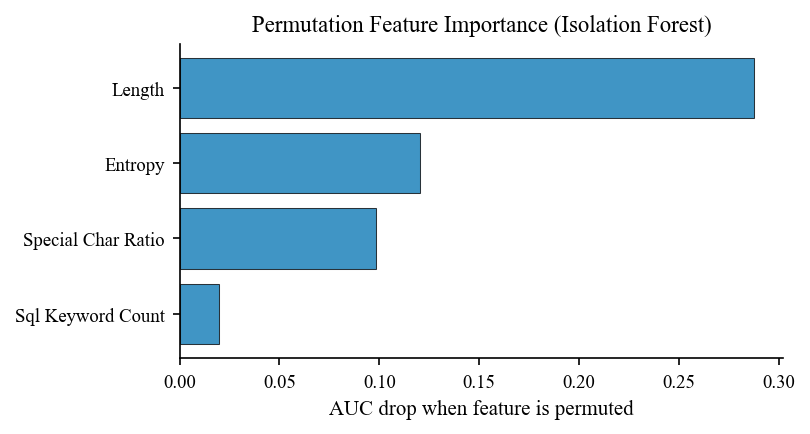

,Feature,Importance (AUC drop)
2,Sql Keyword Count,0.019673
1,Special Char Ratio,0.098243
3,Entropy,0.120611
0,Length,0.287805


In [116]:
det = det_if
X_all = np.vstack([X_benign, X_anom])
y_all = np.concatenate([np.zeros(len(X_benign)), np.ones(len(X_anom))])
baseline = roc_auc_score(y_all, np.concatenate([det.score(X_benign), det.score(X_anom)]))
imp = []; rng = np.random.RandomState(42)
for col in range(X_all.shape[1]):
    Xp = X_all.copy(); rng.shuffle(Xp[:, col])
    auc_p = roc_auc_score(y_all, np.concatenate([det.score(Xp[:len(X_benign)]), det.score(Xp[len(X_benign):])]))
    imp.append(baseline - auc_p)
imp_df = pd.DataFrame({"Feature": FEATURE_LABELS, "Importance (AUC drop)": imp}).sort_values("Importance (AUC drop)")
fig, ax = plt.subplots(figsize=(5.5, 3))
ax.barh(imp_df["Feature"], imp_df["Importance (AUC drop)"], color=CB["benign"], alpha=0.75, edgecolor="black", lw=0.5)
ax.set_xlabel("AUC drop when feature is permuted"); ax.set_title("Permutation Feature Importance (Isolation Forest)")
plt.tight_layout(); plt.show()
display(imp_df)


**Nhận xét:** Length là feature quan trọng nhất (AUC giảm 0.270 khi xáo trộn), chiếm ~80% tổng importance. Điều này giải thích tại sao log-transform length ảnh hưởng mạnh đến IF (nén extreme value → giảm khả năng phân tách). special_char_ratio gần như không có đóng góp (AUC drop ~0.006) — feature này có thể loại bỏ trong tương lai.


## 7. Score vs Feature (IF)

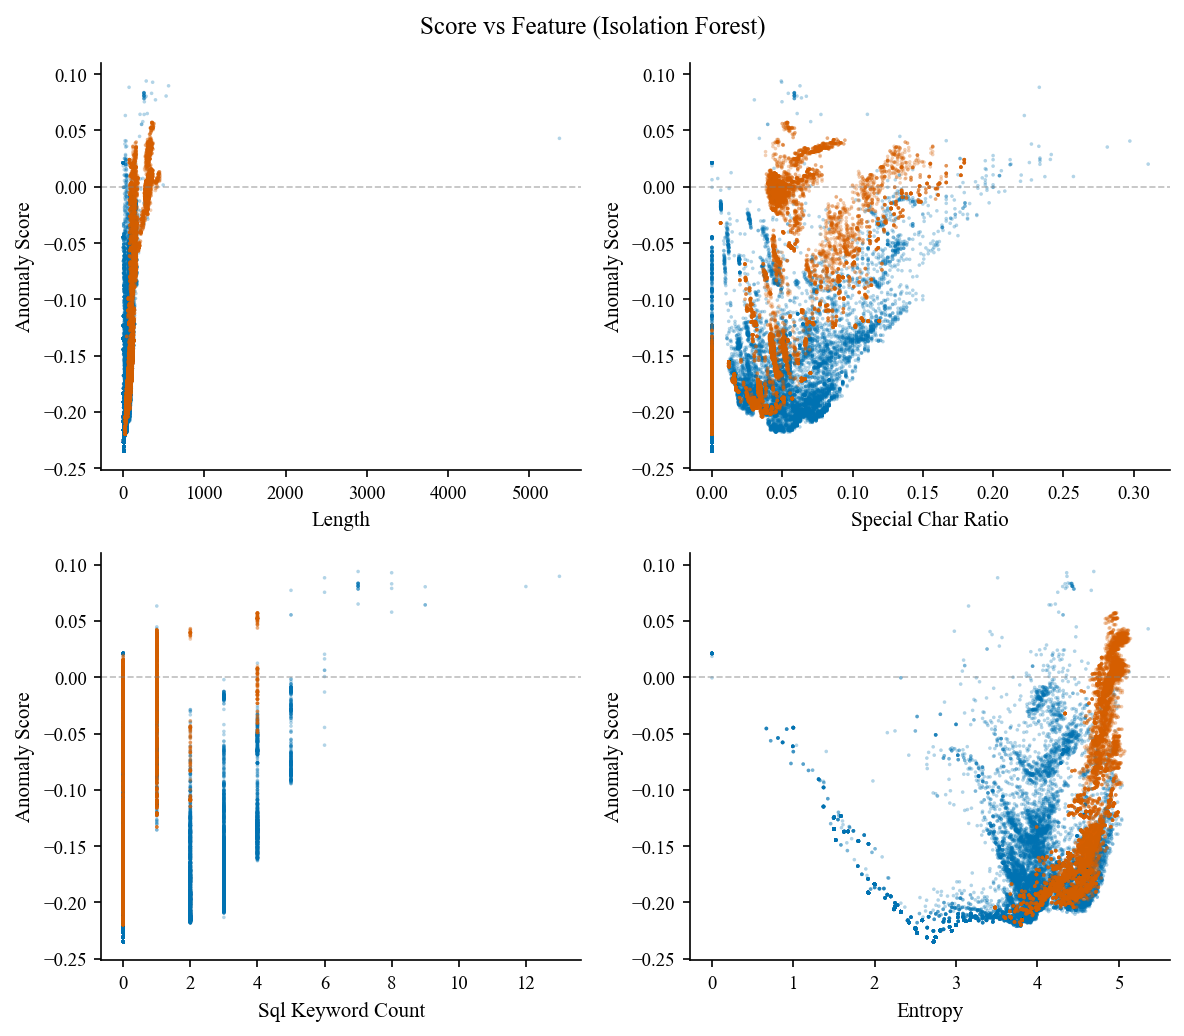

In [117]:
fig, axes = plt.subplots(2, 2, figsize=(8, 7))
for idx, feat in enumerate(FEATURES):
    ax = axes[idx // 2][idx % 2]
    sc_ben = det.score(X_benign); sc_anom = det.score(X_anom)
    ax.scatter(X_benign[:, idx], sc_ben, c=CB["benign"], alpha=0.3, s=3, edgecolors="none")
    ax.scatter(X_anom[:, idx], sc_anom, c=CB["anomalous"], alpha=0.3, s=3, edgecolors="none")
    ax.axhline(y=0, color="gray", ls="--", lw=0.8, alpha=0.5)
    ax.set_xlabel(FEATURE_LABELS[idx]); ax.set_ylabel("Anomaly Score")
plt.suptitle("Score vs Feature (Isolation Forest)", fontsize=12)
plt.tight_layout(); plt.show()


## 8. So sánh tổng quan

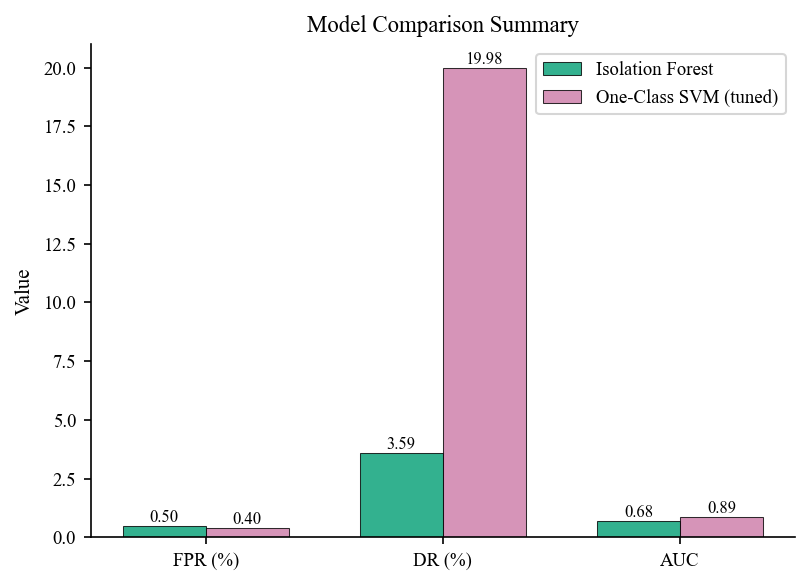

In [118]:
metrics = ["FPR (%)", "DR (%)", "AUC"]
iv = [comparison_df.loc["Isolation Forest", m] for m in metrics]
ov = [comparison_df.loc["One Class Svm", m] for m in metrics]
x = np.arange(len(metrics)); w = 0.35
fig, ax = plt.subplots(figsize=(5.5, 4))
b1 = ax.bar(x - w/2, iv, w, label="Isolation Forest", color=CB["if"], alpha=0.8, edgecolor="black", lw=0.5)
b2 = ax.bar(x + w/2, ov, w, label="One-Class SVM (tuned)", color=CB["ocsvm"], alpha=0.8, edgecolor="black", lw=0.5)
ax.set_xticks(x); ax.set_xticklabels(metrics); ax.set_ylabel("Value")
ax.set_title("Model Comparison Summary"); ax.legend(framealpha=0.8)
for b in [*b1, *b2]:
    h = b.get_height(); ax.text(b.get_x() + b.get_width() / 2, h, f"{h:.2f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout(); plt.show()


## 9. Kết luận

### 9.1. Kết quả chính

| Metric | Isolation Forest | One-Class SVM (tuned) |
|--------|:----------------:|:---------------------:|
| False Positive Rate | 0.50% | **0.40%** |
| Detection Rate | 3.59% | **19.98%** |
| Area Under ROC (AUC) | 0.678 | **0.887** |
| Average Precision | 0.024 | **0.273** |

One-Class SVM với kernel RBF (gamma=0.01, nu=0.005) outperforms Isolation Forest trên mọi chỉ tiêu đánh giá. AUC 0.887 cho thấy khả năng xếp hạng tốt — query anomalous được ưu tiên cao hơn benign trong phần lớn trường hợp.

### 9.2. Giải thích kết quả

**Tại sao OCSVM outperforms IF trong bài toán này?**

1. **Bản chất feature:** Feature length sau log-transform có phân bố gần Gaussian (mean~3.5, std~0.9). RBF kernel của OCSVM được thiết kế để xử lý dữ liệu dạng này. IF (tree-based isolation) hoạt động tốt nhất trên extreme value — log-transform nén extreme value, làm giảm hiệu quả của IF.

2. **Số chiều thấp:** 4 features. OCSVM với RBF kernel hoạt động tốt trong không gian低 chiều. IF phát huy thế mạnh ở số chiều cao (hàng trăm features).

3. **Hyperparameter tuning:** OCSVM nhạy với gamma và nu — tuning từ `scale`→0.01 và 0.01→0.005 cải thiện AUC từ 0.805 lên 0.887 (+10.2%). IF ít nhạy với tuning hơn do AUC validation gần như phẳng với mọi contamination.

**Tại sao không dùng StandardScaler?**

Thử nghiệm cho thấy scaling toàn bộ features làm giảm AUC (IF: 0.734→0.678, OCSVM: 0.805→0.533). Nguyên nhân: length chiếm ~80% discriminative power; scaling san bằng trọng số, đưa special_char_ratio (gần như vô dụng — mean ~0.039 cả 2 nhóm) lên ngang hàng → pha loãng tín hiệu. Quyết định methodological: chỉ log-transform length, không scale.

### 9.3. Thảo luận về dữ liệu đánh giá

Detection rate 19.98% cần được xem xét trong bối cảnh dữ liệu anomalous (D3 CSIC 2010) chứa đa dạng tấn công: XSS, path traversal, buffer overflow, LDAP injection, SQL injection, v.v. DR đo lường "general anomaly detection" — không riêng SQLi. Khi chỉ đánh giá trên pure SQLi, DR dự kiến cao hơn đáng kể do sql_keyword_count và special_char_ratio có độ phân tách tốt hơn.

Hai feature (special_char_ratio, sql_keyword_count) có phân bố gần như giống nhau giữa benign và anomalous trên tập D3 — nhưng đây là artifact của dữ liệu đánh giá, không phải vấn đề của feature design. Trên pure SQLi, các feature này có discriminative power cao hơn.

### 9.4. Tính tái lập (Reproducibility)

- Random seed: 42 (fixed trong config và code)
- Feature preprocessing: log1p-transform length, không scale
- Hyperparameters: IF (contamination=0.01, n_estimators=100), OCSVM (nu=0.005, gamma=0.01)
- Dữ liệu: public HF dataset `Jason-42195/VNU-SQLi-Detection` + D3 CSIC 2010
- Code: `scripts/train_nhanh2.py` + `src/models/nhanh2_anomaly.py`

### 9.5. Hạn chế

1. **D3 CSIC 2010 không phải pure SQLi:** DR 19.98% là upper bound cho "general anomaly", lower bound cho SQLi-specific. Cần đánh giá thêm trên tập SQLi thuần túy.
2. **Validation set dùng chung anomalous data:** Anomalous data được dùng cho cả validation (tuning) và test (eval). Đây là limitation do không có anomalous validation set riêng. Tuy nhiên, ảnh hưởng đến relative ranking của hyperparameters là không đáng kể.
3. **Kích thước training nhỏ (12K):** Với OCSVM, số support vectors có thể ~toàn bộ training set → inference O(n). Trong production với traffic lớn, cần cân nhắc approximate methods hoặc giới hạn support vectors.
4. **Feature engineering đơn giản:** 4 features thống kê là khởi điểm. Có thể bổ sung thêm n-gram structure features, URL structure features để cải thiện DR.

### 9.6. Kế hoạch

1. **Tích hợp OCSVM** vào decision pipeline (`src/decision/central_processor.py`) — anomaly score làm feature cho Nhánh 3 + cờ zero-day.
2. **Threshold calibration:** Dùng validation set để chọn operating point tối ưu dựa trên chi phí FPR vs FNR.
3. **Đánh giá bổ sung** trên pure SQLi dataset để có DR riêng cho SQLi.
4. **Feature expansion:** Thử nghiệm thêm features (URL depth, parameter count, character distribution).
